### CD4 T-cell Gene Set Enrichment Analysis
*Dataset: PICA Batch001–Batch007 (PICA0001–PICA0128)* \
*Analysis: Hallmark pathway enrichment from CD4 pseudobulk DESeq2 results*

#### Aim
This notebook performs gene set enrichment analysis using age-associated DESeq2 results from CD4 T-cell pseudobulk analysis.

Genes are ranked by the DESeq2 test statistic for each CD4 subset, and preranked GSEA is performed using Hallmark gene sets to identify pathways enriched with increasing or decreasing age.

*Note: This notebook uses DESeq2 output files generated in the previous differential expression notebook. It does not perform differential expression testing directly.*

In [1]:
import gseapy as gp
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

deg_dir = Path("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD4")
outdir = Path("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_GSEA/CD4")
outdir.mkdir(exist_ok=True)

deg_files = {
    "CD4_naive_Tcm": deg_dir / "DESeq2_age_CD4_naive_Tcm.csv",
    "CD4_Tem": deg_dir / "DESeq2_age_CD4_Tem.csv",
    "Tfh": deg_dir / "DESeq2_age_Tfh.csv",
    "Treg": deg_dir / "DESeq2_age_Treg.csv",
    "CD4_cytoT": deg_dir / "DESeq2_age_CD4_cytoT.csv"
}

## GSEA

In [ ]:
# Define function to run preranked GSEA
def run_gsea(celltype_name, deg_file):
    
    print(f"Running GSEA for {celltype_name}")
    
    # Load DESeq2 result table
    res = pd.read_csv(deg_file)
    
    # Retain genes with available DESeq2 test statistics
    res = res.dropna(subset=["gene", "stat"])
    
    # Remove duplicated gene entries before ranking
    res = res.drop_duplicates(subset="gene")
    
    # Rank genes by DESeq2 test statistic
    ranking = res[["gene", "stat"]].copy()
    ranking = ranking.sort_values("stat", ascending=False)
    
    # Output folder
    ct_outdir = outdir / celltype_name
    ct_outdir.mkdir(exist_ok=True)
    
    # Run preranked GSEA using Hallmark gene sets
    pre_res = gp.prerank(
        rnk=ranking,
        gene_sets="MSigDB_Hallmark_2020",
        outdir=str(ct_outdir),
        permutation_num=1000,
        seed=42,
        min_size=15,
        max_size=500,
        verbose=True
    )
    
    # Save result table
    gsea_df = pre_res.res2d
    gsea_df.to_csv(ct_outdir / f"GSEA_Hallmark_{celltype_name}.csv")
    
    return gsea_df

In [ ]:
# Run preranked GSEA for each subset with an available DESeq2 result file
all_gsea = {}

for ct, file in deg_files.items():
    if file.exists():
        all_gsea[ct] = run_gsea(ct, file)
    else:
        print(f"Missing file for {ct}: {file}")

2026-05-22 22:03:39,728 [INFO] Parsing data files for GSEA.............................
2026-05-22 22:03:39,744 [INFO] Enrichr library gene sets already downloaded in: /home/s4575250/.cache/gseapy, use local file
2026-05-22 22:03:39,750 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2026-05-22 22:03:39,750 [INFO] 0050 gene_sets used for further statistical testing.....
2026-05-22 22:03:39,750 [INFO] Start to run GSEA...Might take a while..................


Running GSEA for CD4_naive_Tcm


2026-05-22 22:03:49,800 [INFO] Congratulations. GSEApy runs successfully................

2026-05-22 22:03:49,833 [INFO] Parsing data files for GSEA.............................
2026-05-22 22:03:49,847 [INFO] Enrichr library gene sets already downloaded in: /home/s4575250/.cache/gseapy, use local file
2026-05-22 22:03:49,854 [INFO] 0001 gene_sets have been filtered out when max_size=500 and min_size=15
2026-05-22 22:03:49,854 [INFO] 0049 gene_sets used for further statistical testing.....
2026-05-22 22:03:49,855 [INFO] Start to run GSEA...Might take a while..................


Running GSEA for CD4_Tem


2026-05-22 22:03:59,238 [INFO] Congratulations. GSEApy runs successfully................

2026-05-22 22:03:59,276 [INFO] Parsing data files for GSEA.............................
2026-05-22 22:03:59,288 [INFO] Enrichr library gene sets already downloaded in: /home/s4575250/.cache/gseapy, use local file
2026-05-22 22:03:59,293 [INFO] 0002 gene_sets have been filtered out when max_size=500 and min_size=15
2026-05-22 22:03:59,293 [INFO] 0048 gene_sets used for further statistical testing.....
2026-05-22 22:03:59,294 [INFO] Start to run GSEA...Might take a while..................


...

2026-05-22 22:04:07,738 [INFO] Congratulations. GSEApy runs successfully................

2026-05-22 22:04:07,772 [INFO] Parsing data files for GSEA.............................
2026-05-22 22:04:07,783 [INFO] Enrichr library gene sets already downloaded in: /home/s4575250/.cache/gseapy, use local file
2026-05-22 22:04:07,788 [INFO] 0002 gene_sets have been filtered out when max_size=500 and min_size=15
2026-05-22 22:04:07,789 [INFO] 0048 gene_sets used for further statistical testing.....
2026-05-22 22:04:07,789 [INFO] Start to run GSEA...Might take a while..................


Running GSEA for Treg


2026-05-22 22:04:16,229 [INFO] Congratulations. GSEApy runs successfully................

2026-05-22 22:04:16,253 [INFO] Parsing data files for GSEA.............................
2026-05-22 22:04:16,262 [INFO] Enrichr library gene sets already downloaded in: /home/s4575250/.cache/gseapy, use local file
2026-05-22 22:04:16,267 [INFO] 0003 gene_sets have been filtered out when max_size=500 and min_size=15
2026-05-22 22:04:16,267 [INFO] 0047 gene_sets used for further statistical testing.....
2026-05-22 22:04:16,267 [INFO] Start to run GSEA...Might take a while..................


Running GSEA for CD4_cytoT


2026-05-22 22:04:24,214 [INFO] Congratulations. GSEApy runs successfully................



In [14]:
# Combine GSEA results
combined = []

for ct, df in all_gsea.items():
    temp = df.copy()
    temp["cell_type"] = ct
    combined.append(temp)

gsea_combined = pd.concat(combined, axis=0)

gsea_combined.to_csv(outdir / "CD4_GSEA_Hallmark_combined.csv", index=False)

gsea_combined.head()

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,cell_type
0,prerank,Myc Targets V1,-0.57734,-2.71002,0.0,0.0,0.0,119/199,24.76%,RAD23B;NOP16;EIF3B;VDAC1;PPM1G;STARD7;PSMB2;EI...,CD4_naive_Tcm
1,prerank,G2-M Checkpoint,-0.558729,-2.603577,0.0,0.0,0.0,110/190,24.86%,SMC4;MAP3K20;RAD23B;BARD1;TACC3;CENPE;EZH2;ATF...,CD4_naive_Tcm
2,prerank,Mitotic Spindle,-0.50663,-2.367516,0.0,0.0,0.0,85/189,20.78%,SMC4;EPB41;CD2AP;TRIO;PCNT;RAPGEF5;CENPE;KPTN;...,CD4_naive_Tcm
3,prerank,Myc Targets V2,-0.593337,-2.277063,0.0,0.0,0.0,29/57,17.92%,NOP16;TFB2M;SLC19A1;TCOF1;PPRC1;WDR43;NOLC1;IP...,CD4_naive_Tcm
4,prerank,Oxidative Phosphorylation,-0.4719,-2.261566,0.0,0.0,0.0,93/198,22.19%,SLC25A5;ATP5F1C;VDAC1;ATP5F1B;IDH2;IMMT;NDUFA9...,CD4_naive_Tcm


### Significant GSEA pathways

In [15]:
gsea_combined.columns

Index(['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val',
       'Tag %', 'Gene %', 'Lead_genes', 'cell_type'],
      dtype='object')

In [ ]:
# Retain pathways passing the FDR threshold
sig_gsea = gsea_combined[
    gsea_combined["FDR q-val"] < 0.05
].copy()

# Sort significant pathways by cell type and FDR
sig_gsea = sig_gsea.sort_values(
    ["cell_type", "FDR q-val"]
)

sig_gsea.to_csv(
    outdir / "CD4_GSEA_Hallmark_significant.csv",
    index=False
)

sig_gsea.head(20)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,cell_type
0,prerank,Oxidative Phosphorylation,-0.537006,-2.558137,0.0,0.0,0.0,99/198,19.12%,ATP5F1C;COX5A;SLC25A5;ATP5F1B;TIMM8B;ATP5MF;ID...,CD4_Tem
1,prerank,Interferon Alpha Response,-0.591522,-2.474018,0.0,0.0,0.0,52/94,17.38%,CD74;PARP12;UBE2L6;OASL;IL7;CCRL2;PSME2;LAP3;T...,CD4_Tem
2,prerank,G2-M Checkpoint,-0.523302,-2.421001,0.0,0.0,0.0,77/186,18.14%,SMC4;KNL1;CENPE;EZH2;LMNB1;JPT1;NUSAP1;DR1;CKS...,CD4_Tem
3,prerank,Interferon Gamma Response,-0.50687,-2.351518,0.0,0.0,0.0,84/177,17.69%,CD74;CD38;PSMB2;PARP12;UBE2L6;SAMHD1;OASL;MVP;...,CD4_Tem
4,prerank,mTORC1 Signaling,-0.451682,-2.109474,0.0,0.0,0.0,83/191,19.84%,PSMA4;SHMT2;SEC11A;SLC6A6;BCAT1;PSMD13;HPRT1;P...,CD4_Tem
5,prerank,Mitotic Spindle,-0.449729,-2.104808,0.0,0.0,0.0,66/186,14.54%,SMC4;CAPZB;CENPE;LMNB1;NUSAP1;MYO1E;FLNB;NET1;...,CD4_Tem
6,prerank,PI3K/AKT/mTOR Signaling,-0.48852,-2.058469,0.0,0.000314,0.001,39/94,14.17%,PFN1;ARPC3;PPP1CA;YWHAB;UBE2N;AP2M1;CSNK2B;MYD...,CD4_Tem
7,prerank,E2F Targets,-0.423993,-1.964954,0.0,0.001373,0.005,76/192,21.68%,SMC4;CENPE;EZH2;LMNB1;JPT1;SMC6;CKS2;HMGA1;HMG...,CD4_Tem
9,prerank,Cholesterol Homeostasis,-0.472503,-1.807563,0.0,0.003515,0.015,26/65,14.34%,ACTG1;GNAI1;ANXA5;FABP5;SQLE;LDLR;CHKA;PPARG;T...,CD4_Tem
8,prerank,Reactive Oxygen Species Pathway,-0.504754,-1.842053,0.002457,0.003661,0.014,22/46,18.63%,PDLIM1;TXN;LAMTOR5;LSP1;NQO1;NDUFA6;TXNRD1;HMO...,CD4_Tem


In [ ]:
# Summary table
gsea_summary = sig_gsea[[
    "cell_type",
    "Term",
    "NES",
    "NOM p-val",
    "FDR q-val"
]].copy()

# Annotate enrichment direction based on normalised enrichment score
gsea_summary["direction"] = gsea_summary["NES"].apply(
    lambda x: "Up with age" if x > 0 else "Down with age"
)

# Sort pathways by cell type and significance
gsea_summary = gsea_summary.sort_values(
    ["cell_type", "FDR q-val"]
)

gsea_summary.to_csv(
    outdir / "CD4_GSEA_Hallmark_summary.csv",
    index=False
)

gsea_summary.head(30)

,cell_type,Term,NES,NOM p-val,FDR q-val,direction
0,CD4_Tem,Oxidative Phosphorylation,-2.558137,0.0,0.0,Down with age
1,CD4_Tem,Interferon Alpha Response,-2.474018,0.0,0.0,Down with age
2,CD4_Tem,G2-M Checkpoint,-2.421001,0.0,0.0,Down with age
3,CD4_Tem,Interferon Gamma Response,-2.351518,0.0,0.0,Down with age
4,CD4_Tem,mTORC1 Signaling,-2.109474,0.0,0.0,Down with age
5,CD4_Tem,Mitotic Spindle,-2.104808,0.0,0.0,Down with age
6,CD4_Tem,PI3K/AKT/mTOR Signaling,-2.058469,0.0,0.000314,Down with age
7,CD4_Tem,E2F Targets,-1.964954,0.0,0.001373,Down with age
9,CD4_Tem,Cholesterol Homeostasis,-1.807563,0.0,0.003515,Down with age
8,CD4_Tem,Reactive Oxygen Species Pathway,-1.842053,0.002457,0.003661,Down with age


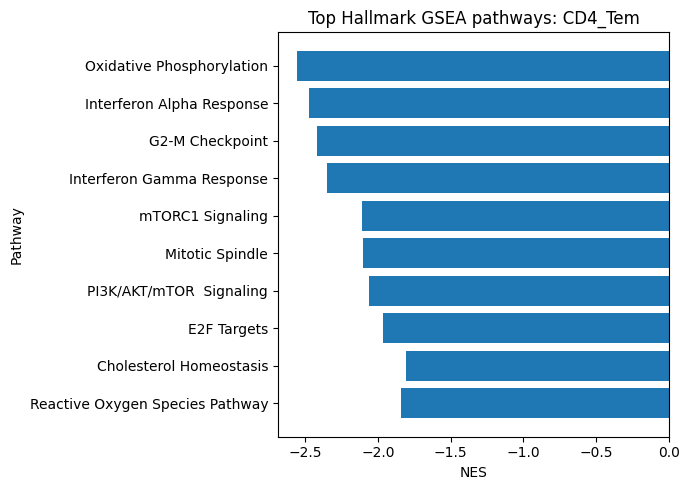

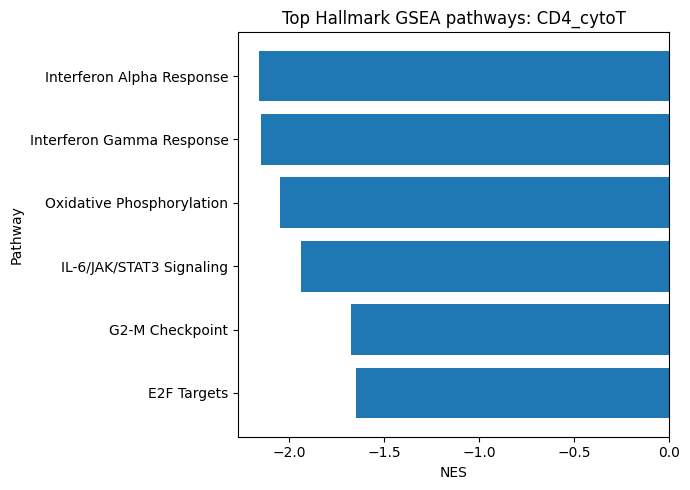

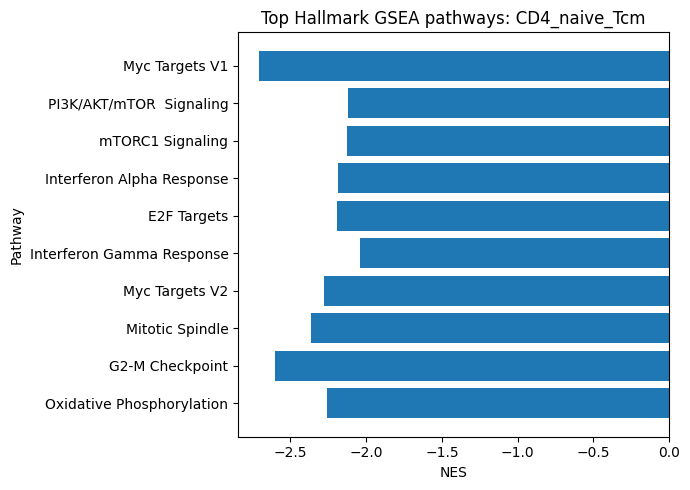

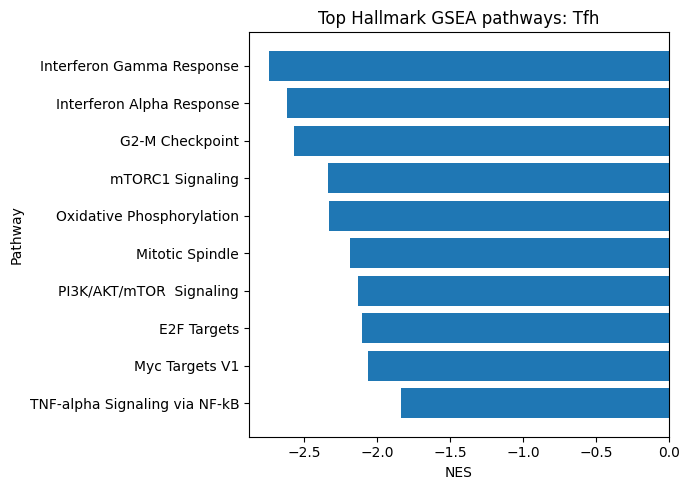

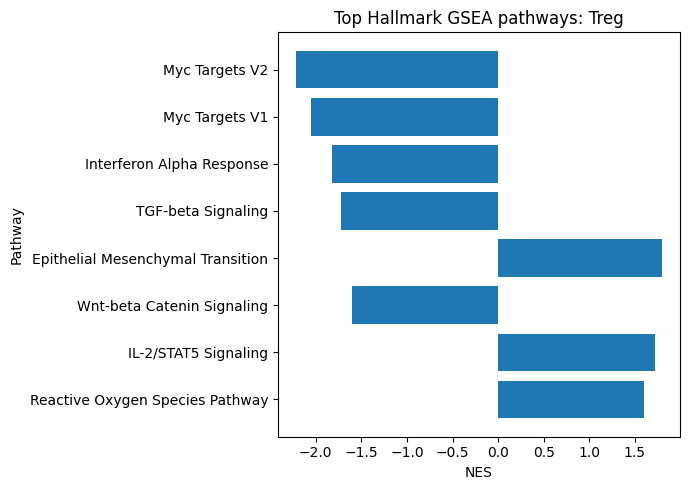

In [18]:
# Plot top GSEA pathways per cell type
for ct in gsea_summary["cell_type"].unique():
    
    df = gsea_summary[gsea_summary["cell_type"] == ct].copy()
    df = df.sort_values("FDR q-val").head(10)
    
    if df.empty:
        continue
    
    plt.figure(figsize=(7, 5))
    plt.barh(df["Term"], df["NES"])
    plt.xlabel("NES")
    plt.ylabel("Pathway")
    plt.title(f"Top Hallmark GSEA pathways: {ct}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    
    plt.savefig(outdir / f"GSEA_top_pathways_{ct}.png", dpi=300)
    plt.show()